The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


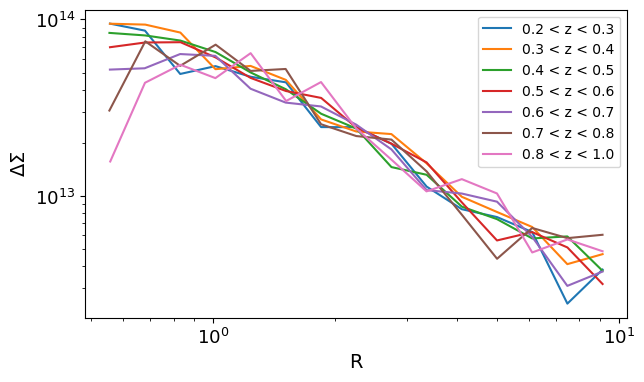

In [4]:
%load_ext autoreload
%autoreload 2
import numpy as np
import sys
import matplotlib.pyplot as plt
sys.path.append('../../')
import _redshift_richness_bins as analysis

plt.figure(figsize=(7,4))
index = 12
fmt = ['-', '--', '.']
suff = '_full_coverage'
path_to_data = '../../../CLCosmo_Sim_database/data/'
data_true = np.load(path_to_data + f'stacked_esd_profiles_redmapper_true{suff}.pkl', allow_pickle=True)
profiles_true = data_true['stacked profile']
z = data_true['stacked profile']['z_mean']
for z_bin in analysis.Z_bin:
    mask = (z > z_bin[0])*(z < z_bin[1])
    r = np.mean(profiles_true['radius'][mask], axis=0)
    ds = np.mean(profiles_true['gt'][mask], axis=0)
    plt.loglog(r, ds, label=f'{z_bin[0]:.1f} < z < {z_bin[1]:.1f}')
plt.xscale('log')
plt.ylabel(r'$\Delta\Sigma$', fontsize=14)
plt.xlabel('R', fontsize=14)
plt.legend()
plt.tick_params(axis='both', which="both", labelsize= 13)
#plt.savefig('../fig/stacked_redmapper_profiles_attenuation.png', bbox_inches='tight', dpi=100)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


142
[ 9.85556278  9.33223251 11.20996592  7.50919582  8.67942282  6.31371983
  4.7018299 ]
73
[14.01180417  8.45569663  9.47670721 11.86758004 12.50985491  8.84445042
  6.74976725]
14
[4.53528711 6.77313394 6.79520425 2.51709481 7.27298678 4.32504761
 2.39838972]
6
[4.80308801 6.57429239 4.34578457 2.47684627 2.95903478 5.73530803
 2.62526098]


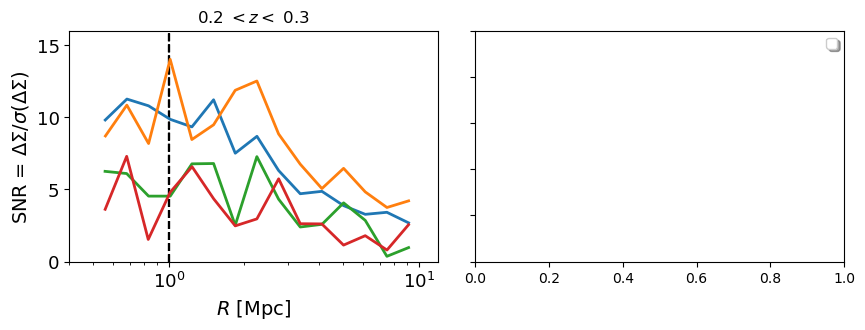

In [21]:
data = np.load(path_to_data + f'stacked_esd_profiles_redmapper_true{suff}.pkl', allow_pickle=True)
profiles = data['stacked profile']
covariances = data['stacked covariance']
Z_bin = analysis.Z_bin
Obs_bin = analysis.Obs_bin
n_z_bin = len(Z_bin) 
n_m_bin = len(Obs_bin) 
fig, axs = plt.subplots(1,2, figsize = (10, 3))
fig.subplots_adjust(wspace=0.1, hspace=0.1)
for i, z_bin in enumerate([Z_bin[0]]):
    for j, m_bin in enumerate(Obs_bin):

            label_z =   f'{z_bin[0]:.1f} $< z <$ {z_bin[1]:.1f}'
            label_M = f'{m_bin[0]:.0f} < ' + r'$\lambda$' +f' < {m_bin[1]:.0f}'
            mask_z = (profiles['z_mean'] > z_bin[0])*(profiles['z_mean'] < z_bin[1])
            mask_m = (profiles['obs_mean'] > m_bin[0])*(profiles['obs_mean'] < m_bin[1])
            index = np.arange(len(profiles))
            index_cut = index[mask_m * mask_z]
            f_cut = profiles[index_cut]
            N = len(f_cut['z_individual'][0])
            print(N)
            cov = np.array(covariances['cov_t'][index_cut])
            err = cov.T.diagonal()**.5
            print(f_cut['gt'][0][(f_cut['radius'][0] > 1)*(f_cut['radius'][0] < 3.5)]/err[0][(f_cut['radius'][0] > 1)*(f_cut['radius'][0] < 3.5)])
            axs[i].errorbar(f_cut['radius'][0], f_cut['gt'][0]/err[0] ,lw=2,
                            marker = ' ',fmt = '-', elinewidth = 2,  markersize = 2, markerfacecolor = None, label = label_M)
            axs[i].set_ylim(0, 16)
            axs[i].set_xlim(0.4, 12)
            axs[i].set_xscale('log')
            #axs[i].set_yscale('log')
            axs[i].vlines(1, 0, 1e19, ls='--', color='k')
            axs[i].tick_params(axis='both', which = 'major', labelsize= 13)
            #axs[0].legend(frameon = False, loc = 'upper right', fontsize = 10)
            axs[i].set_xlabel(r'$R$ [Mpc]', fontsize = 14)
            axs[i].set_title(label_z, fontsize = 12)
            axs[0].set_ylabel(r'SNR = $\Delta\Sigma/\sigma(\Delta\Sigma)$', fontsize=14)
            #axs[i].grid('True', which='both')
        #except: a=1
        
axs[1].legend(loc='upper right',# bbox_to_anchor=(-2.5, 1.4),
      #fancybox=True,
           ncol=2,
           shadow=True)

for ax in fig.get_axes():
    ax.label_outer()
#plt.savefig('../fig/snr_ds_profiles.png', bbox_inches='tight', dpi=300)

In [14]:
sys.path.append('../modules')
import _load_data
path_to_data = '../../../CLCosmo_Sim_database/data/'
lensing_data_truez = path_to_data + 'stacked_esd_profiles_redmapper_true_full_coverage.pkl'
lensing_data_bpz = path_to_data + 'stacked_esd_profiles_redmapper_BPZ_full_coverage.pkl'
lensing_data_flex = path_to_data + 'stacked_esd_profiles_redmapper_flex_full_coverage.pkl'
#baseline
analysis_Duffy08_baseline = {'type': 'WLxN',
                            'fit_cosmo':'False',
                            'density_profile':'nfw',
                            'cM_relation':'Duffy08',
                            'two_halo':'False',
                            'hmf':'Despali16',
                            'radius_max':3.5,
                            'radius_min':1.,
                            'photoz':'Truez',
                            'shear_richness_cov':'False',
                            'redshift_range':'Full',
                            'richness_range':'Full',
                            'redshift_bin_index': np.arange(len(analysis.Z_bin)),
                            'richness_bin_index': np.arange(len(analysis.Obs_bin)),
                            'redshift_corner_index': np.arange(len(analysis.z_corner)),
                            'richness_corner_index': np.arange(len(analysis.rich_corner)),
                            'lensing_data':lensing_data_truez,
                            'add_bias_lensing':'False',
                            'name_plot':'baseline'}
N_obs, DS_obs, Err_obs, mask_is_in_fit_range = _load_data.load_data(analysis_Duffy08_baseline, Z_bin, Obs_bin, analysis.z_corner, analysis.rich_corner)



[load data]: counts
[load data]: stacked lensing profiles and errors


In [15]:
#DS_obs = np.zeros([len(r), len(Richness_bin), len(Z_bin)])

[ 9.85556278  9.33223251 11.20996592  7.50919582  8.67942282  6.31371983
  4.7018299 ]
[14.01180417  8.45569663  9.47670721 11.86758004 12.50985491  8.84445042
  6.74976725]
[4.53528711 6.77313394 6.79520425 2.51709481 7.27298678 4.32504761
 2.39838972]
[4.80308801 6.57429239 4.34578457 2.47684627 2.95903478 5.73530803
 2.62526098]


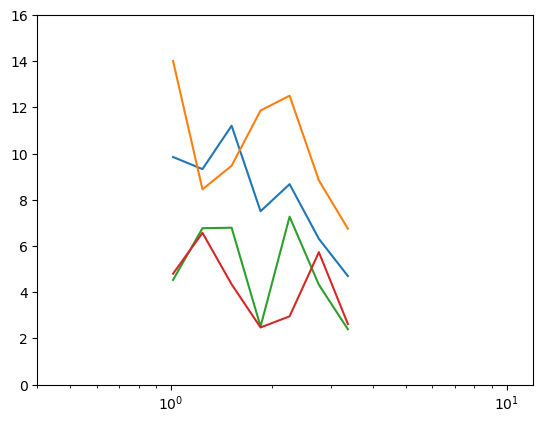

In [24]:
for i in range(len(Obs_bin)):
    plt.plot(f_cut['radius'][0][(f_cut['radius'][0] > 1)*(f_cut['radius'][0] < 3.5)], DS_obs[:,i,0]/Err_obs[:,i,0])
    print(DS_obs[:,i,0]/Err_obs[:,i,0])
plt.ylim(0, 16)
plt.xlim(0.4, 12)
plt.xscale('log')